# Preliminary

In [1]:
!git clone https://github.com/sht037-lgtm/Q-Vtree.git

Cloning into 'Q-Vtree'...
remote: Enumerating objects: 491, done.
remote: Counting objects: 100% (111/111), done.
remote: Compressing objects: 100% (81/81), done.
remote: Total 491 (delta 55), reused 79 (delta 25), pack-reused 380 (from 1)
Receiving objects: 100% (491/491), 27.78 MiB | 42.26 MiB/s, done.
Resolving deltas: 100% (269/269), done.


In [ ]:
# log in HuggingFace
!pip install -U huggingface_hub
!hf auth login --token "input your hf token here"

!pip install qwen-vl-utils[decord]==0.0.8

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 616.3/616.3 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 108.8 MB/s eta 0:00:0000:01
  Attempting uninstall: hf-xet
    Found existing installation: hf-xet 1.2.0
    Uninstalling hf-xet-1.2.0:
      Successfully uninstalled hf-xet-1.2.0
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `hf`CLI if you want to set the git credential as well.
Token is valid (permission: read).
The token `ZoomEye` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.cache/huggingface/token
Login successful.
The current active token is: `ZoomEye`
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/3

In [3]:
# download Qwen2.5-VL-3B-Instruct Model
%cd Q-Vtree/checkpoints
!python download.py
!ls

/kaggle/working/Q-Vtree/checkpoints
[INFO] Downloading Qwen/Qwen2.5-VL-3B-Instruct ...
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:190: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(
Fetching 14 files: 100%|████████████████████████| 14/14 [00:17<00:00,  1.27s/it]
Download complete: : 7.52GB [00:17, 811MB/s]              [INFO] Download complete: /kaggle/working/Q-Vtree/checkpoints/Qwen2.5-VL-3B-Instruct
Model path: /kaggle/working/Q-Vtree/checkpoints/Qwen2.5-VL-3B-Instruct
Download complete: : 7.52GB [00:17, 422MB/s]
download.py  Qwen2.5-VL-3B-Instruct


In [4]:
%cd /kaggle/working/Q-Vtree

# load base qwen model
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
import torch

model_path = "checkpoints/Qwen2.5-VL-3B-Instruct"

processor = AutoProcessor.from_pretrained(model_path)

base_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_path,
    torch_dtype=torch.float16,
    device_map="auto"
)
base_model.eval()

print("base model loaded")

/kaggle/working/Q-Vtree


The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

base model loaded


In [5]:
# load tree qwen model
from qwen.model import Qwen2_5_VLForConditionalGenerationWithTree

tree_model = Qwen2_5_VLForConditionalGenerationWithTree.from_pretrained(
    model_path,
    torch_dtype=torch.float16,
    device_map="auto"
)
tree_model.eval()

print("tree model loaded")

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

tree model loaded


# Demo

In [6]:
!ls img

demo_1.jpg	     demo_3_heatmap.png  demo_4_selected.png  demo_6.jpeg
demo_2_heatmap.png   demo_3.jpeg	 demo_5_heatmap.png   demo_7.jpeg
demo_2.jpeg	     demo_4_heatmap.png  demo_5.jpeg	      demo_8.jpeg
demo_2_selected.png  demo_4.jpeg	 demo_5_selected.png


In [7]:
demo_img = "img/demo_6.jpeg"

In [9]:
# format input
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": demo_img},
            {"type": "text", "text": "What breed is the dog in the image?"}
        ],
    }
]

text = processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)

from qwen_vl_utils import process_vision_info
image_inputs, video_inputs = process_vision_info(messages)

inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)

device = next(tree_model.parameters()).device
inputs = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in inputs.items()}

In [19]:
# generation
with torch.inference_mode():
    outputs = tree_model.generate(**inputs, max_new_tokens=64)

decoded = processor.batch_decode(
    outputs[:, inputs["input_ids"].shape[1]:],
    skip_special_tokens=True
)

print("Output:", decoded)

Output: ['The dog in the image appears to be a Belgian Malinois, also known as a Belgian Shepherd Dog or simply a Malinois. This breed is known for its intelligence, loyalty, and versatility, often used in police work, military service, and as a working dog. The Belgian Malinois has a distinctive coat color,']


In [20]:
# check tree
selected_nodes = tree_model.model._debug_selected_idx

print("Selected nodes per image:")
for i, nodes in enumerate(selected_nodes):
    print(f"Image {i}: {len(nodes)} nodes")

patch_ids = tree_model.model._debug_patch_ids

print("Selected patches:", len(patch_ids[0]))
print("Total patches:", inputs["pixel_values"].size(0)//4)

Selected nodes per image:
Image 0: 22 nodes
Selected patches: 107
Total patches: 740


In [21]:
patch_ids

[tensor([ 92,  93,  94,  95, 129, 130, 131, 132, 133, 135, 166, 167, 168, 169,
         170, 172, 205, 206, 242, 243, 314, 316, 317, 320, 321, 322, 351, 353,
         354, 357, 358, 359, 379, 380, 381, 382, 383, 384, 385, 386, 387, 416,
         417, 418, 419, 420, 421, 422, 423, 424, 448, 449, 450, 451, 452, 453,
         454, 455, 456, 457, 458, 459, 460, 461, 485, 486, 487, 488, 489, 490,
         491, 492, 493, 494, 495, 496, 497, 498, 522, 523, 524, 525, 526, 527,
         528, 529, 530, 531, 532, 533, 534, 535, 561, 562, 563, 564, 565, 569,
         571, 572, 600, 601, 602, 605, 606, 607, 637], device='cuda:0')]

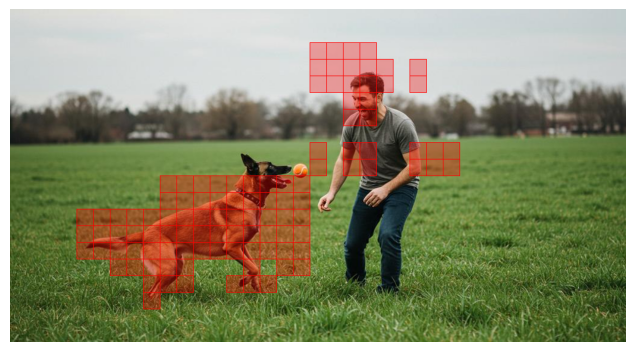

In [23]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

# selected patches
patch_ids = tree_model.model._debug_patch_ids[0]

# downsampled grid size
grid_h = inputs["image_grid_thw"][0][1].item() // 2
grid_w = inputs["image_grid_thw"][0][2].item() // 2

patch_size = 28
image_w = grid_w * patch_size
image_h = grid_h * patch_size

# load image
img = Image.open(demo_img).convert("RGB").resize((image_w, image_h))

overlay = Image.new("RGBA", img.size, (0, 0, 0, 0))
draw = ImageDraw.Draw(overlay)

for idx in patch_ids.tolist():
    r = idx // grid_w
    c = idx % grid_w

    x0 = int(c * patch_size)
    y0 = int(r * patch_size)
    x1 = int((c + 1) * patch_size)
    y1 = int((r + 1) * patch_size)

    draw.rectangle(
        [x0, y0, x1, y1],
        fill=(255, 0, 0, 80),
        outline=(255, 0, 0, 255),
    )

out = Image.alpha_composite(img.convert("RGBA"), overlay)

plt.figure(figsize=(8, 8 * image_h / image_w))
plt.imshow(out)
plt.axis("off")

# plt.savefig(f"{demo_img}_selected.png", dpi=300)
plt.show()

/tmp/ipykernel_55/129592511.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  scores = torch.tensor(scores, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # [1,1,H,W]


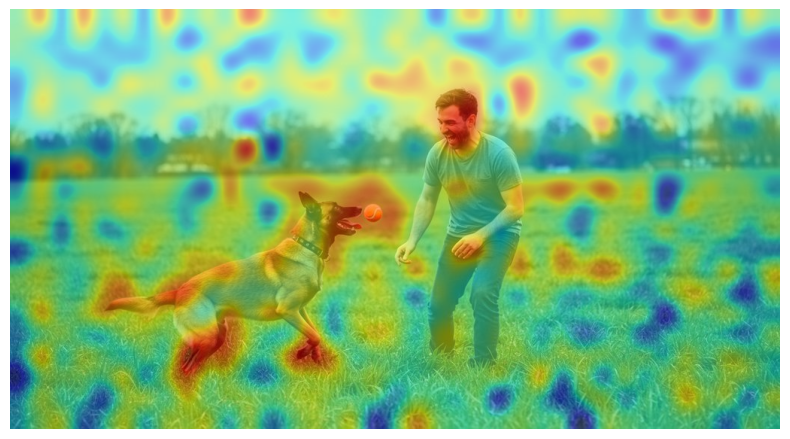

In [25]:
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn.functional as F
import torch

# patch scores
scores = tree_model.model.qvtree._debug_patch_scores[0].detach().cpu()

# real downsampled grid
grid_h = inputs["image_grid_thw"][0][1].item() // 2
grid_w = inputs["image_grid_thw"][0][2].item() // 2

if scores.numel() != grid_h * grid_w:
    raise ValueError(
        f"Score/grid mismatch: scores={scores.numel()}, grid=({grid_h}, {grid_w}), H*W={grid_h * grid_w}"
    )

# reshape to rectangular grid
scores = scores.reshape(grid_h, grid_w)

# normalize
scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-6)

# load original image
img = Image.open(demo_img).convert("RGB")
orig_w, orig_h = img.size

# smooth interpolation to image size
scores = torch.tensor(scores, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # [1,1,H,W]
scores = F.interpolate(
    scores,
    size=(orig_h, orig_w),
    mode="bicubic",
    align_corners=False
)
scores = scores.squeeze().numpy()

plt.figure(figsize=(10, 10 * orig_h / orig_w))
plt.imshow(img)
plt.imshow(scores, cmap="jet", alpha=0.5)
plt.axis("off")

# plt.savefig(f"{demo_img}_heatmap.png", dpi=300)
plt.show()

# Evaluation

In [26]:
# download evaluation datasets (vstar,hrbench)
%cd datasets
!python download.py
!ls
%cd ..

from qwen.evaluate import (
    run_vstar_inference,
    evaluate_vstar_predictions,
    run_hrbench_inference,
    evaluate_hrbench_predictions,
)

/kaggle/working/Q-Vtree/datasets
[INFO] Downloading VStar dataset from: craigwu/vstar_bench
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:190: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(
Fetching 478 files: 100%|█████████████████████| 478/478 [00:22<00:00, 21.27it/s]
Download complete: : 380MB [00:22, 14.7MB/s]                                    [INFO] VStar download complete.
[INFO] Downloading HR-Bench from: DreamMr/HR-Bench


Fetching 7 files:   0%|                                   | 0/7 [00:00<?, ?it/s]

Fetching 7 files:  14%|███▊                       | 1/7 [00:00<00:02,  2.14it/s]

Fetching 7 files:  57%|███████████████▍           | 4/7 [00:12<00:10,  3.35s/it]
Download complete: : 380MB [00:40, 14.7MB/s] 7.26G/9.82G [00:15<00:41, 61.0MB/s]

Fetching 7 files: 100%|███████████████████████████| 7/7 [00:35<00:00,  5.07s/it]

Download complete

In [27]:
# base qwen + vstar
pred_file = run_vstar_inference(
    model=base_model,
    processor=processor,
    model_type="base_qwen",
    run_name="base_qwen_vstar",
    max_samples=10,
)
evaluate_vstar_predictions(pred_file)

Running V-Star inference [base_qwen]:  10%|█         | 1/10 [00:06<01:01,  6.81s/it]

[ERROR][base_qwen] question_id=0: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.



Running V-Star inference [base_qwen]:  20%|██        | 2/10 [00:07<00:24,  3.01s/it]

[ERROR][base_qwen] question_id=1: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.



Running V-Star inference [base_qwen]:  30%|███       | 3/10 [00:07<00:12,  1.79s/it]

...

Running V-Star inference [base_qwen]:  90%|█████████ | 9/10 [00:09<00:00,  2.26it/s]

[ERROR][base_qwen] question_id=8: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.



Running V-Star inference [base_qwen]: 100%|██████████| 10/10 [00:09<00:00,  1.02it/s]

[ERROR][base_qwen] question_id=9: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.

[INFO] Saved predictions to: datasets/vstar_bench/vstar_predictions_base_qwen_vstar.jsonl
Accuracy: 0.0000 (0/10)


0.0

In [28]:
# tree qwen + vstar
pred_file = run_vstar_inference(
    model=tree_model,
    processor=processor,
    model_type="tree_qwen",
    run_name="tree_qwen_vstar",
    max_samples=10,
)
evaluate_vstar_predictions(pred_file)

Running V-Star inference [tree_qwen]:  10%|█         | 1/10 [00:00<00:02,  3.45it/s]

[ERROR][tree_qwen] question_id=0: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.



Running V-Star inference [tree_qwen]:  20%|██        | 2/10 [00:00<00:02,  3.25it/s]

[ERROR][tree_qwen] question_id=1: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.



Running V-Star inference [tree_qwen]:  30%|███       | 3/10 [00:00<00:02,  3.28it/s]

...

Running V-Star inference [tree_qwen]:  90%|█████████ | 9/10 [00:02<00:00,  3.21it/s]

[ERROR][tree_qwen] question_id=8: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.



Running V-Star inference [tree_qwen]: 100%|██████████| 10/10 [00:03<00:00,  3.28it/s]

[ERROR][tree_qwen] question_id=9: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.

[INFO] Saved predictions to: datasets/vstar_bench/vstar_predictions_tree_qwen_vstar.jsonl
Accuracy: 0.0000 (0/10)


0.0

In [29]:
# base qwen + hrbench 4k
pred_file = run_hrbench_inference(
    model=base_model,
    processor=processor,
    split="4k",
    model_type="base_qwen",
    run_name="base_qwen_hrbench4k",
    max_samples=10,
)
evaluate_hrbench_predictions(pred_file)

Running HR-Bench 4k [base_qwen]:  10%|█         | 1/10 [00:01<00:12,  1.37s/it]

[ERROR][base_qwen] index=0: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.



Running HR-Bench 4k [base_qwen]:  20%|██        | 2/10 [00:02<00:10,  1.27s/it]

[ERROR][base_qwen] index=1: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.



Running HR-Bench 4k [base_qwen]:  30%|███       | 3/10 [00:03<00:08,  1.24s/it]

...

Running HR-Bench 4k [base_qwen]:  90%|█████████ | 9/10 [00:11<00:01,  1.21s/it]

[ERROR][base_qwen] index=8: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.



Running HR-Bench 4k [base_qwen]: 100%|██████████| 10/10 [00:12<00:00,  1.23s/it]

[ERROR][base_qwen] index=9: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.

[INFO] Saved predictions to: datasets/hr_bench/hr_bench_4k_predictions_base_qwen_hrbench4k.jsonl
Accuracy: 0.0000 (0/10)


0.0

In [ ]:
# tree qwen + hrbench 4k
pred_file = run_hrbench_inference(
    model=tree_model,
    processor=processor,
    split="4k",
    model_type="tree_qwen",
    run_name="tree_qwen_hrbench4k",
    max_samples=10,
)
evaluate_hrbench_predictions(pred_file)

In [ ]:
# base qwen + hrbench 8k
pred_file = run_hrbench_inference(
    model=base_model,
    processor=processor,
    split="8k",
    model_type="base_qwen",
    run_name="base_qwen_hrbench8k",
    max_samples=10,
)
evaluate_hrbench_predictions(pred_file)

In [ ]:
# tree qwen + hrbench 8k
pred_file = run_hrbench_inference(
    model=tree_model,
    processor=processor,
    split="8k",
    model_type="tree_qwen",
    run_name="tree_qwen_hrbench8k",
    max_samples=10,
)
evaluate_hrbench_predictions(pred_file)